In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import (
    densenet121, DenseNet121_Weights,
    resnet50, ResNet50_Weights,
    efficientnet_v2_m, EfficientNet_V2_M_Weights,
    alexnet, AlexNet_Weights,
)
from torchvision import transforms
from huggingface_hub import hf_hub_download


In [3]:
# Configuración de semillas para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")


Dispositivo utilizado: cuda


# EDA de las galaxias DESI/HSC con `enyasantos/galaxy-classification-v02`

En lugar de imágenes sintéticas, este notebook utiliza las primeras `N_MUESTRAS` imágenes del archivo HDF5 indicado. Las imágenes se redimensionan a 224×224 y se pasan por el ensemble publicado. Para cada una de las cuatro CNN se extrae el vector de 128 características previo a la capa final, obteniendo 512 características por galaxia.

Además, se conservan las predicciones de las 10 clases del modelo. El ensemble utiliza **mean voting**, por lo que se promedian las probabilidades de las cuatro CNN. Esto permite explorar la distribución morfológica estimada de la muestra y la confianza de las predicciones.

**Importante:** estas etiquetas corresponden a las clases de Galaxy10 SDSS, que es el conjunto con el que fue entrenado el modelo. Por tanto, en las imágenes DESI/HSC de este notebook deben interpretarse como **clasificaciones estimadas por el modelo**, no como etiquetas de verdad terreno.


In [4]:
# ==========================================
# 1. CARGA DEL DATASET HDF5
# ==========================================
import numpy as np

PATH = "/content/drive/MyDrive/galaxiesML/DESI_HSC_64x64_v2.hdf5"


f = h5py.File(PATH, "r")
images_3chan = f['image'][:]
f.close()
print(images_3chan.shape)


(134533, 5, 64, 64)


In [5]:
# ==========================================
# 2. PREPARAR LAS IMÁGENES PARA EL ENSEMBLE
# ==========================================
# El modelo publicado recibe imágenes RGB.
# Aceptamos tanto NHWC como NCHW y, si hubiera más de 3 canales,
# usamos los primeros tres de forma explícita.

images = np.asarray(images_3chan)

if images.ndim != 4:
    raise ValueError(f'Se esperaba un arreglo 4-D de imágenes, pero se obtuvo {images.shape}')

# Convertir a NHWC.
if images.shape[-1] in (3, 4):
    images_rgb = images[..., :3]
elif images.shape[1] >= 3:
    images_rgb = np.transpose(images[:, :3, :, :], (0, 2, 3, 1))
else:
    raise ValueError(f'No se encontraron al menos 3 canales RGB en {images.shape}')

# Normalización a uint8 solamente si los datos no están ya en [0, 255].
# La transformación posterior de torchvision convierte la imagen a [0,1].
if np.issubdtype(images_rgb.dtype, np.floating):
    lo, hi = np.nanmin(images_rgb), np.nanmax(images_rgb)
    print(f'Rango original de las imágenes: [{lo:.4g}, {hi:.4g}]')
    if lo >= 0 and hi <= 1:
        images_rgb = (images_rgb * 255).clip(0, 255).astype(np.uint8)
    else:
        # Escalamiento global robusto para poder visualizar/procesar imágenes científicas.
        p1, p99 = np.nanpercentile(images_rgb, [1, 99])
        images_rgb = ((images_rgb - p1) / (p99 - p1 + 1e-8) * 255).clip(0, 255).astype(np.uint8)
else:
    images_rgb = images_rgb.clip(0, 255).astype(np.uint8)

print(f'Dimensiones finales para el modelo (NHWC): {images_rgb.shape}')


Rango original de las imágenes: [-633.2, 1688]
Dimensiones finales para el modelo (NHWC): (134533, 64, 64, 3)


In [7]:
# ==========================================
# 2. EXTRACCIÓN DE DESCRIPTORES CON
#    enyasantos/galaxy-classification-v02
# ==========================================
#
# El repositorio contiene un ensemble de cuatro CNN:
#   - EfficientNet-V2-M
#   - DenseNet121
#   - ResNet50
#   - AlexNet
#
# Cada CNN tiene un clasificador personalizado:
#   features -> 256 -> 128 -> 10 clases
#
# Para el EDA no utilizamos la salida de clasificación (10 clases).
# Extraemos el vector de 128 características justo antes de la última
# capa de clasificación de cada CNN y concatenamos los cuatro vectores:
#
#                 128 x 4 = 512 características por imagen.
#
# Modelo: https://huggingface.co/enyasantos/galaxy-classification-v02

REPO_ID = "enyasantos/galaxy-classification-v02"

MODEL_FILES = {
    "EfficientNet-V2-M": "models/EfficientNet-V2-M.pth",
    "DenseNet121": "models/DenseNet121.pth",
    "ResNet50": "models/ResNet50.pth",
    "AlexNet": "models/AlexNet.pth",
}

def changed_classifier_layer(model, model_name, n_classes=10):
    """Reproduce the classifier used by the published ensemble."""
    for param in model.parameters():
        param.requires_grad = False

    if model_name == "DenseNet121":
        num_input = model.classifier.in_features
    elif model_name == "ResNet50":
        num_input = model.fc.in_features
    else:
        num_input = model.classifier[1].in_features

    classifier = nn.Sequential(
        nn.Linear(num_input, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, n_classes),
        nn.LogSoftmax(dim=1),
    )

    if model_name == "ResNet50":
        model.fc = classifier
    else:
        model.classifier = classifier

    return model


def load_galaxy_models():
    """Download the four published checkpoints and recreate the ensemble."""
    model_builders = {
        "EfficientNet-V2-M": lambda: efficientnet_v2_m(
            weights=EfficientNet_V2_M_Weights.IMAGENET1K_V1
        ),
        "DenseNet121": lambda: densenet121(
            weights=DenseNet121_Weights.IMAGENET1K_V1
        ),
        "ResNet50": lambda: resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        ),
        "AlexNet": lambda: alexnet(
            weights=AlexNet_Weights.IMAGENET1K_V1
        ),
    }

    models = {}
    for name, filename in MODEL_FILES.items():
        print(f"Cargando {name}...")

        model = changed_classifier_layer(model_builders[name](), name)

        weights_path = hf_hub_download(
            repo_id=REPO_ID,
            filename=filename
        )
        state_dict = torch.load(weights_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        models[name] = model

    return models


# Preprocesamiento estándar de ImageNet.
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])






In [8]:
# ==========================================\n
# 3. EXTRACCIÓN DE DESCRIPTORES Y PREDICCIONES (HOOKS)
# ==========================================\n
BATCH_SIZE = 32

feature_blocks = []
model_probabilities = {}

galaxy_models = load_galaxy_models()

with torch.inference_mode():
    for name, model in galaxy_models.items():
        model_features = []
        model_probs = []

        # 1. Variable auxiliar para almacenar la salida intermedia
        captured_layer_output = {}

        def get_activation():
            def hook(module, input, output):
                captured_layer_output['features'] = output
            return hook

        # 2. Registrar el hook en la capa Linear(256, 128) -> Índice 3 del clasificador
        if name == "ResNet50":
            hook_handle = model.fc[3].register_forward_hook(get_activation())
        else:
            hook_handle = model.classifier[3].register_forward_hook(get_activation())

        # 3. Inferencia por lotes
        for start in range(0, len(images_rgb), BATCH_SIZE):
            batch_np = images_rgb[start:start + BATCH_SIZE]
            batch = torch.stack([image_transform(img) for img in batch_np]).to(device)

            # En una Sola Pasada se calcula el Forward completo
            log_probs = model(batch)
            probs = torch.exp(log_probs)
            model_probs.append(probs.cpu().numpy())

            # El hook captura automáticamente las 128 características durante model(batch)
            feats_128 = captured_layer_output['features']
            model_features.append(feats_128.cpu().numpy())

        # 4. Remover el hook para liberar memoria/referencias
        hook_handle.remove()

        model_features = np.concatenate(model_features, axis=0)
        model_probs = np.concatenate(model_probs, axis=0)

        print(f'{name}: features={model_features.shape}, probabilities={model_probs.shape}')
        feature_blocks.append(model_features)
        model_probabilities[name] = model_probs

# Concatenar los 4 modelos (4 x 128 = 512 características por imagen)
features = np.concatenate(feature_blocks, axis=1)

# Mean voting para el ensemble
ensemble_probabilities = np.mean(
    np.stack(list(model_probabilities.values()), axis=0),
    axis=0
)
ensemble_predictions = np.argmax(ensemble_probabilities, axis=1)
ensemble_confidence = np.max(ensemble_probabilities, axis=1)

print(f'\nDimensiones de los descriptores concatenados: {features.shape}')
print(f'Dimensiones de las probabilidades del ensemble: {ensemble_probabilities.shape}')

Cargando EfficientNet-V2-M...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 206MB/s]


models/EfficientNet-V2-M.pth: reconstructing file:   0%|          |  0.00B /  214MB            

models/EfficientNet-V2-M.pth: downloading bytes:           |  0.00B            

Cargando DenseNet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

Cargando AlexNet...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 196MB/s]


models/AlexNet.pth: reconstructing file:   0%|          |  0.00B / 19.5MB            

models/AlexNet.pth: downloading bytes:           |  0.00B            

EfficientNet-V2-M: features=(134533, 128), probabilities=(134533, 10)
DenseNet121: features=(134533, 128), probabilities=(134533, 10)
ResNet50: features=(134533, 128), probabilities=(134533, 10)
AlexNet: features=(134533, 128), probabilities=(134533, 10)

Dimensiones de los descriptores concatenados: (134533, 512)
Dimensiones de las probabilidades del ensemble: (134533, 10)


Distribución de las galaxias según el ensemble:


,Código,Clase,Número de galaxias,Porcentaje
0,2,Round Smooth Galaxies,133314,99.093903
1,7,Unbarred Loose Spiral Galaxies,878,0.652628
2,0,Disturbed Galaxies,334,0.248266
3,1,Merging Galaxies,5,0.003717
4,3,In-between Round Smooth Galaxies,2,0.001487
5,4,Cigar Shaped Smooth Galaxies,0,0.000000
6,5,Barred Spiral Galaxies,0,0.000000
7,6,Unbarred Tight Spiral Galaxies,0,0.000000
8,8,Edge-on Galaxies without Bulge,0,0.000000
9,9,Edge-on Galaxies with Bulge,0,0.000000


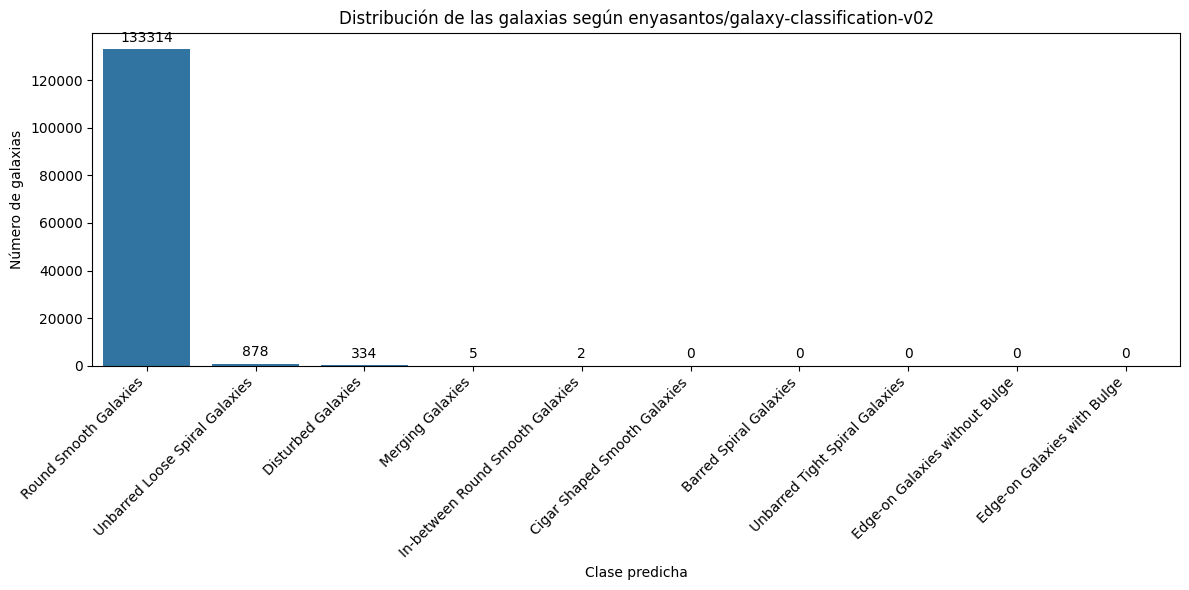

Confianza media del ensemble: 0.491
Confianza mediana del ensemble: 0.496


,P_0_Disturbed Galaxies,P_1_Merging Galaxies,P_2_Round Smooth Galaxies,P_3_In-between Round Smooth Galaxies,P_4_Cigar Shaped Smooth Galaxies,P_5_Barred Spiral Galaxies,P_6_Unbarred Tight Spiral Galaxies,P_7_Unbarred Loose Spiral Galaxies,P_8_Edge-on Galaxies without Bulge,P_9_Edge-on Galaxies with Bulge,Clase_predicha,Clase_predicha_nombre,Confianza
0,0.259118,0.002672,0.487480,0.000223,0.000352,3.812740e-08,1.049208e-05,0.250106,6.479015e-06,3.146806e-05,2,Round Smooth Galaxies,0.487480
1,0.253274,0.000951,0.495731,0.000018,0.000016,4.243134e-11,1.348263e-07,0.250008,1.495167e-07,9.948005e-07,2,Round Smooth Galaxies,0.495731
2,0.251871,0.000500,0.497588,0.000023,0.000016,1.137307e-12,1.268750e-08,0.250002,1.911749e-08,1.582589e-07,2,Round Smooth Galaxies,0.497588
3,0.258128,0.002398,0.488943,0.000169,0.000249,1.906426e-08,6.798954e-06,0.250080,4.327570e-06,2.169114e-05,2,Round Smooth Galaxies,0.488943
4,0.252295,0.000670,0.496954,0.000051,0.000026,4.419495e-12,3.143384e-08,0.250004,4.087085e-08,3.120313e-07,2,Round Smooth Galaxies,0.496954


In [9]:
# ==========================================
# 4. DISTRIBUCIÓN DE LAS CLASIFICACIONES
# ==========================================
# El modelo fue entrenado para 10 clases de Galaxy10 SDSS.
# Las etiquetas son las definidas por el conjunto Galaxy10.
GALAXY10_CLASSES = {
    0: 'Disturbed Galaxies',
    1: 'Merging Galaxies',
    2: 'Round Smooth Galaxies',
    3: 'In-between Round Smooth Galaxies',
    4: 'Cigar Shaped Smooth Galaxies',
    5: 'Barred Spiral Galaxies',
    6: 'Unbarred Tight Spiral Galaxies',
    7: 'Unbarred Loose Spiral Galaxies',
    8: 'Edge-on Galaxies without Bulge',
    9: 'Edge-on Galaxies with Bulge',
}

# Predicción final del ensemble (mean voting).
predicted_class_names = [GALAXY10_CLASSES[i] for i in ensemble_predictions]

classification_counts = pd.Series(predicted_class_names).value_counts()
classification_distribution = pd.DataFrame({
    'Clase': list(GALAXY10_CLASSES.values()),
    'Código': list(GALAXY10_CLASSES.keys()),
})
classification_distribution['Número de galaxias'] = (
    classification_distribution['Código']
    .map(pd.Series(ensemble_predictions).value_counts())
    .fillna(0)
    .astype(int)
)
classification_distribution['Porcentaje'] = (
    100 * classification_distribution['Número de galaxias'] / len(ensemble_predictions)
)
classification_distribution = classification_distribution.sort_values(
    'Número de galaxias', ascending=False
).reset_index(drop=True)

print('Distribución de las galaxias según el ensemble:')
display(classification_distribution[['Código', 'Clase', 'Número de galaxias', 'Porcentaje']])

# Gráfica de la distribución.
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=classification_distribution,
    x='Clase',
    y='Número de galaxias'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Número de galaxias')
plt.xlabel('Clase predicha')
plt.title('Distribución de las galaxias según enyasantos/galaxy-classification-v02')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.tight_layout()
plt.show()

# Confianza del ensemble: probabilidad promedio asignada a la clase predicha.
print(f'Confianza media del ensemble: {ensemble_confidence.mean():.3f}')
print(f'Confianza mediana del ensemble: {np.median(ensemble_confidence):.3f}')

# Guardamos los resultados por muestra para poder relacionarlos después con
# otras variables del HDF5 (por ejemplo, espectros).
df_classification = pd.DataFrame(ensemble_probabilities, columns=[
    f'P_{i}_{GALAXY10_CLASSES[i]}' for i in range(10)
])
df_classification['Clase_predicha'] = ensemble_predictions
df_classification['Clase_predicha_nombre'] = predicted_class_names
df_classification['Confianza'] = ensemble_confidence

df_classification.head()


In [10]:
# ==========================================
# 5. REDUCCIÓN DE DIMENSIONALIDAD (PCA - 95%)
# ==========================================
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=0.95, random_state=42)
features_pca = pca.fit_transform(features_scaled)

print(
    f'Número de componentes retenidas para el 95% de varianza: '
    f'{features_pca.shape[1]}'
)
print(f'Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4f}')


Número de componentes retenidas para el 95% de varianza: 5
Varianza explicada acumulada: 0.9670


In [11]:
# DataFrame con las componentes principales
pc_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
df_pca = pd.DataFrame(features_pca, columns=pc_columns)
print(df_pca.shape)
df_pca.head()


(134533, 5)


,PC1,PC2,PC3,PC4,PC5
0,-10.887611,-15.830053,-3.746815,1.414005,2.373899
1,-12.378086,-0.608753,-4.921197,0.083063,0.003753
2,0.506981,5.014857,-6.732455,1.404430,1.442504
3,-14.699864,-13.090155,-5.341429,0.513180,1.593704
4,-4.319460,2.634484,-11.501929,2.160266,1.037039


## Etiquetas

El código de carga proporcionado no recupera una variable objetivo de las imágenes. Por ello no se inventan etiquetas. En su lugar, la nueva sección de clasificación usa las **predicciones del propio ensemble** para describir la distribución estimada de tipos de galaxias.


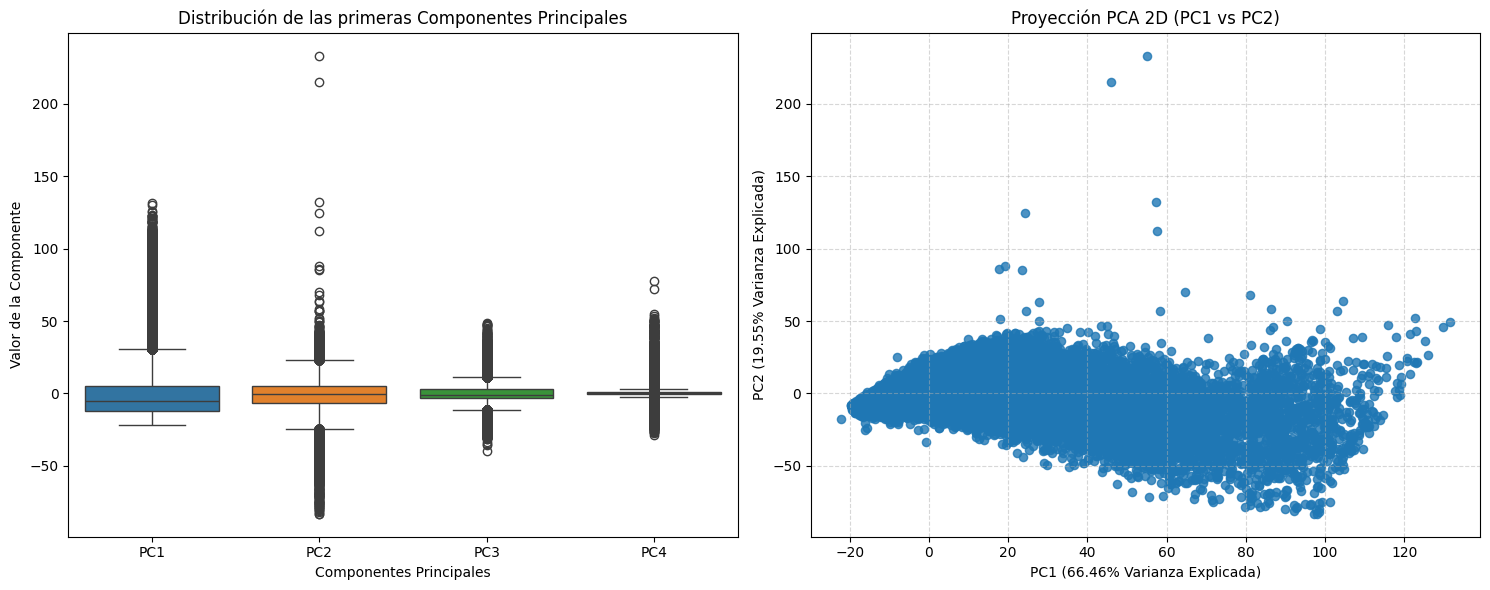

In [12]:
# ==========================================
# 6. VISUALIZACIÓN DE LOS DESCRIPTORES
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A. Distribución de las primeras componentes principales
num_pcs_to_plot = min(4, features_pca.shape[1])
df_first_pcs = df_pca.iloc[:, :num_pcs_to_plot]
sns.boxplot(data=df_first_pcs, ax=axes[0])
axes[0].set_title('Distribución de las primeras Componentes Principales')
axes[0].set_xlabel('Componentes Principales')
axes[0].set_ylabel('Valor de la Componente')

# B. Scatterplot PC1 vs PC2
if features_pca.shape[1] >= 2:
    axes[1].scatter(df_pca['PC1'], df_pca['PC2'], s=35, alpha=0.8)
    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    axes[1].set_title('Proyección PCA 2D (PC1 vs PC2)')
    axes[1].set_xlabel(f'PC1 ({var_pc1:.2f}% Varianza Explicada)')
    axes[1].set_ylabel(f'PC2 ({var_pc2:.2f}% Varianza Explicada)')
    axes[1].grid(True, linestyle='--', alpha=0.5)
else:
    axes[1].text(0.5, 0.5, 'PCA produjo una sola componente', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
# # ==========================================
# # 7. RESUMEN DE LA INFORMACIÓN ESPECTRAL
# # ==========================================
# print('Wave:')
# print(f'  shape = {wave.shape}')
# print(f'  rango = [{np.nanmin(wave):.4g}, {np.nanmax(wave):.4g}]')
# print('Flux:')
# print(f'  shape = {flux.shape}')
# print(f'  rango = [{np.nanmin(flux):.4g}, {np.nanmax(flux):.4g}]')


In [18]:
# ==========================================
# 8. CARGA REDSHIFTS
# ==========================================
import numpy as np

PATH = "/content/drive/MyDrive/galaxiesML/DESI_HSC_64x64_v2.hdf5"


f = h5py.File(PATH, "r")
redshifts = f['DESI_fibermap/DESI_redshift'][:]
f.close()
print(images_3chan.shape)


(134533, 5, 64, 64)


In [19]:
# Crear un DataFrame de Pandas para facilitar el análisis
pc_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
df_pca = pd.DataFrame(features_pca, columns=pc_columns)
df_pca['redshift']=redshifts

df_pca.shape

(134533, 6)

In [20]:
df_pca

,PC1,PC2,PC3,PC4,PC5,redshift
0,-10.887611,-15.830053,-3.746815,1.414005,2.373899,2.170708
1,-12.378086,-0.608753,-4.921197,0.083063,0.003753,0.575945
2,0.506981,5.014857,-6.732455,1.404430,1.442504,0.373673
3,-14.699864,-13.090155,-5.341429,0.513180,1.593704,2.389632
4,-4.319460,2.634484,-11.501929,2.160266,1.037039,0.510228
...,...,...,...,...,...,...
134528,7.637256,17.952562,-6.056008,3.017606,-0.430377,0.292470
134529,-12.522157,-3.607503,-8.502767,0.598242,1.420994,0.779047
134530,-8.066569,-4.434836,-7.206059,1.005827,1.192285,0.377062
134531,-13.347064,-8.967533,-6.529589,0.341784,1.403415,1.736138


In [22]:
# ==========================================
# 9. CÁLCULO DE CORRELACIONES COMPONENTES PRINCIPALES Y REDSHIFT
# ==========================================
# correlación de Pearson
from scipy.stats import pearsonr
correlations = {}
p_values = {}

for pc in pc_columns:
    corr, p_val = pearsonr(df_pca['redshift'], df_pca[pc])
    correlations[pc] = corr
    p_values[pc] = p_val

df_corr = pd.DataFrame({
    'Correlación': correlations,
    'p-value': p_values
}).sort_values(by='Correlación', key=abs, ascending=False)

print("\n--- Índices de Correlación respecto a la Variable Objetivo ---")
print(df_corr.head(10))


--- Índices de Correlación respecto a la Variable Objetivo ---
     Correlación       p-value
PC1    -0.471433  0.000000e+00
PC2    -0.279097  0.000000e+00
PC3    -0.250565  0.000000e+00
PC5     0.040819  1.024813e-50
PC4     0.025449  1.001396e-20
